In [30]:
#IMPORTING LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt


In [31]:
#LOADING DATASET
file_path = r"../data/Bosch_Demand_Datasheet.xlsx"

df = pd.read_excel(file_path, sheet_name = "Premium Blue")
df.head(20)

,Year,Demand: Blue
0,2008-01-01,90
1,2008-02-01,86
2,2008-03-01,76
3,2008-04-01,115
4,2008-05-01,110
5,2008-06-01,104
6,2008-07-01,118
7,2008-08-01,119
8,2008-09-01,110
9,2008-10-01,125


In [32]:
#FORMATTING DATASET
df = df.rename(
    columns = {
        "Year" : "Date",
        "Demand: Blue" : "Demand"
    }
)

df["Date"] = pd.to_datetime(df["Date"])
df.head(10)

df["Demand"].describe()

count    108.000000
mean     119.833333
std       17.303503
min       76.000000
25%      110.000000
50%      122.000000
75%      133.000000
max      152.000000
Name: Demand, dtype: float64

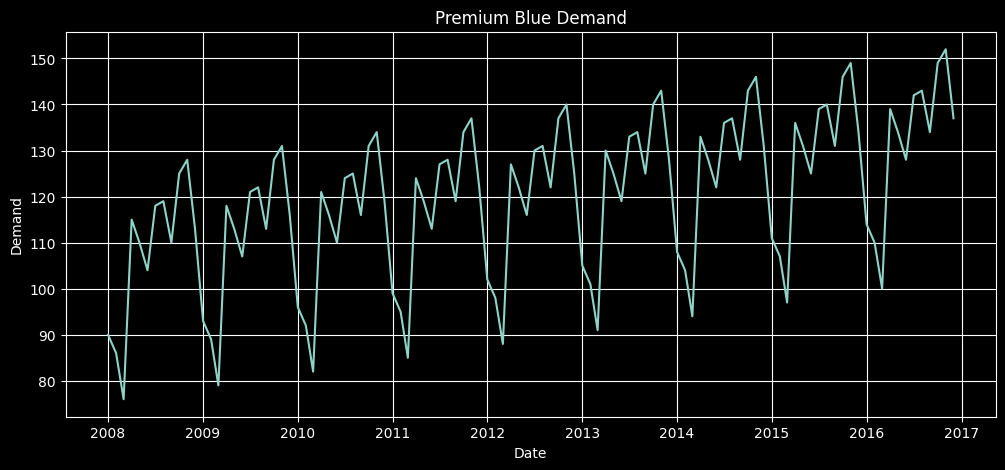

In [33]:
#PLOTTING ACTUAL DEMAND
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"])
plt.title("Premium Blue Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.grid(True)
plt.show()

In [34]:
df["Month"] = df["Date"].dt.month
df.head(48)

,Date,Demand,Month
0,2008-01-01,90,1
1,2008-02-01,86,2
2,2008-03-01,76,3
3,2008-04-01,115,4
4,2008-05-01,110,5
5,2008-06-01,104,6
6,2008-07-01,118,7
7,2008-08-01,119,8
8,2008-09-01,110,9
9,2008-10-01,125,10


In [35]:
#TESTING SES HYPOTHESIS
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
ses_model = SimpleExpSmoothing(df["Demand"]).fit(optimized=True)
print("Alpha: ", ses_model.params["smoothing_level"])

Alpha:  0.7317427640058732


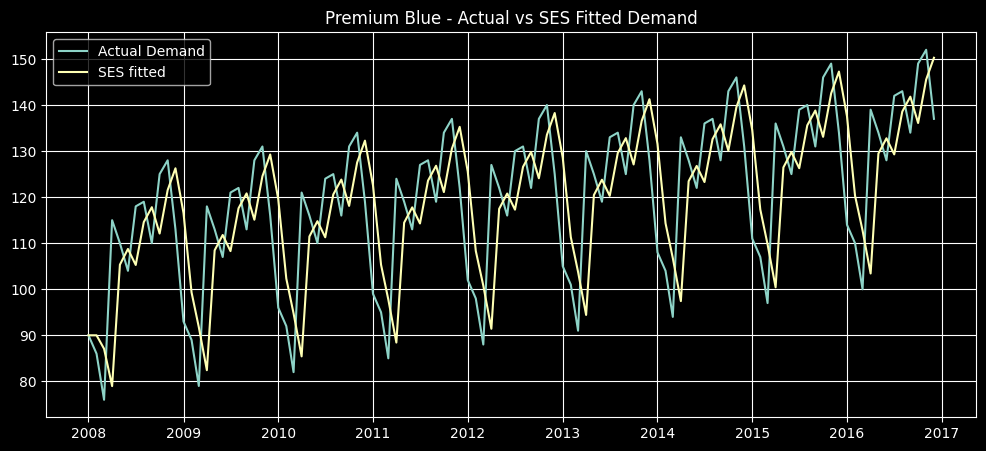

In [49]:
#PLOTTING ACTUAL DEMAND VS SES FITTED DEMAND
df["SES_fitted"] = ses_model.fittedvalues

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"], label="Actual Demand")
plt.plot(df["Date"], df["SES_fitted"], label="SES fitted")
plt.title("Premium Blue - Actual vs SES Fitted Demand")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
#SES ERROR CALCULATION
df["Error"] = df["Demand"] - df["SES_fitted"]
df["Abs_Error"] = abs(df["Error"])

mae = df["Abs_Error"].mean()
print("MAE for SES: ", mae)

df["Abs_Pct_Error"] = (df["Abs_Error"]/df["Demand"])*100
mape = df["Abs_Pct_Error"].mean()
print("MAPE for SES: ", mape,"%")
df.head(30)

MAE for SES:  12.139704679091105
MAPE for SES:  10.407608265162375 %


,Date,Demand,Month,SES_fitted,Error,Abs_Error,Abs_Pct_Error
0,2008-01-01,90,1,90.000000,0.000000,0.000000,0.000000
1,2008-02-01,86,2,90.000000,-4.000000,4.000000,4.651163
2,2008-03-01,76,3,87.073029,-11.073029,11.073029,14.569775
3,2008-04-01,115,4,78.970420,36.029580,36.029580,31.330069
4,2008-05-01,110,5,105.334804,4.665196,4.665196,4.241087
5,2008-06-01,104,6,108.748528,-4.748528,4.748528,4.565892
6,2008-07-01,118,7,105.273827,12.726173,12.726173,10.784892
7,2008-08-01,119,8,114.586112,4.413888,4.413888,3.709150
8,2008-09-01,110,9,117.815943,-7.815943,7.815943,7.105402
9,2008-10-01,125,10,112.096683,12.903317,12.903317,10.322653


In [38]:
#HOLT MODEL HYPOTHESIS TESTING
from statsmodels.tsa.holtwinters import Holt
holt_model = Holt(df["Demand"]).fit(optimized=True)
print(holt_model.params)

{'smoothing_level': np.float64(0.7991804408003833), 'smoothing_trend': np.float64(0.024572018843800843), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(90.0), 'initial_trend': np.float64(-4.0), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


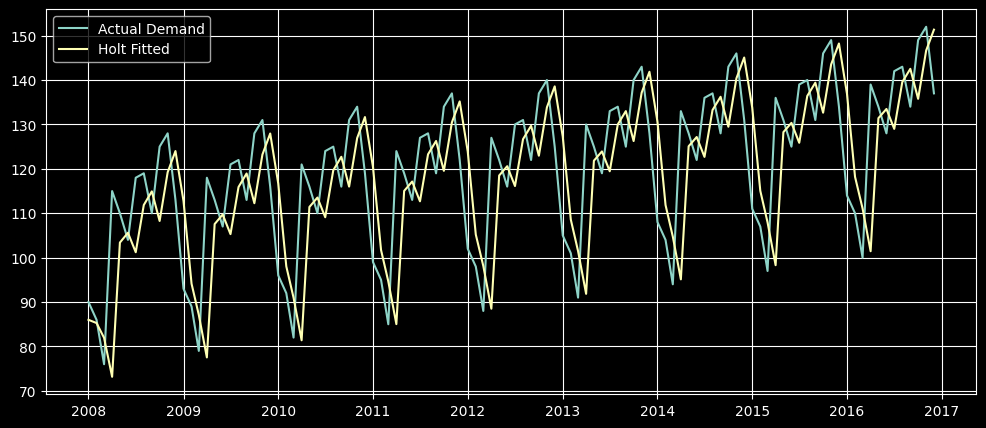

In [39]:
#PLOTTING ACTUAL VS HOLT FITTED DEMAND
df["Holt_Fitted"] = holt_model.fittedvalues
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"], label="Actual Demand")
plt.plot(df["Date"], df["Holt_Fitted"], label="Holt Fitted")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
#HOLT MODEL ERROR CALCULATION
df["Holt_Error"] = df["Demand"] - df["Holt_Fitted"]
df["Holt_Abs_Error"] = abs(df["Holt_Error"])

holt_mae = df["Holt_Abs_Error"].mean()
print("MAE for Holt: ", holt_mae)

df["Holt_Abs_Pct_Error"] = (df["Holt_Abs_Error"]/df["Demand"])*100
holt_mape = df["Holt_Abs_Pct_Error"].mean()
print("MAPE for Holt: ", holt_mape,"%")

MAE for Holt:  11.938126695538937
MAPE for Holt:  10.057326660772219 %


In [41]:
#TESTING HOLT-WINTERS HYPOTHESIS
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    df["Demand"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit(optimized=True)

print(hw_model.params)

{'smoothing_level': np.float64(0.9999999757275572), 'smoothing_trend': np.float64(0.291654939535317), 'smoothing_seasonal': np.float64(4.729988076046129e-10), 'damping_trend': nan, 'initial_level': np.float64(106.32372985138781), 'initial_trend': np.float64(0.24998456152772294), 'initial_seasons': array([-16.57372352, -20.82372294, -31.07372066,   7.67628134,
         2.42628542,  -3.82371178,   9.92628901,  10.67628815,
         1.42628649,  16.17628232,  18.92627891,   3.67627769]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


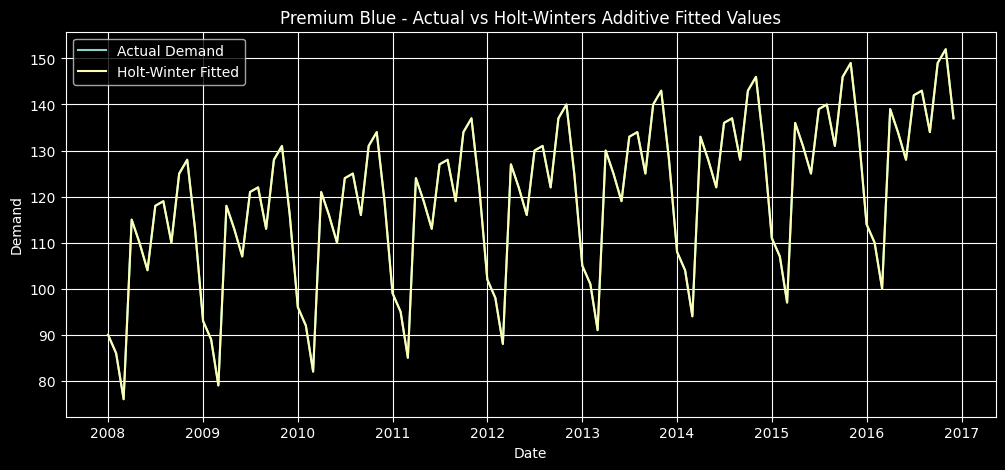

In [50]:
#PLOTTING ACTUAL VS HOLT-WINTERS FITTED DEMAND
df["HW_Fitted"] = hw_model.fittedvalues
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"], label="Actual Demand")
plt.plot(df["Date"], df["HW_Fitted"], label="Holt-Winter Fitted")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Premium Blue - Actual vs Holt-Winters Additive Fitted Values")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
df["HW_Error"] = df["Demand"] - df["HW_Fitted"]

print(df["HW_Error"].describe())

count    1.080000e+02
mean     5.414507e-07
std      2.941947e-06
min     -3.469323e-06
25%     -1.973287e-06
50%     -4.094026e-07
75%      2.490656e-06
max      1.220329e-05
Name: HW_Error, dtype: float64


In [44]:
#HOLT-WINTERS ERROR CALCULATION
df["HW_Abs_Error"] = abs(df["HW_Error"])
df["HW_Abs_Pct_Error"] = (df["HW_Abs_Error"] / df["Demand"]) * 100

print("HW MAE :", df["HW_Abs_Error"].mean())
print("HW MAPE:", df["HW_Abs_Pct_Error"].mean(),"%")

HW MAE : 2.427535757002867e-06
HW MAPE: 2.124431097114791e-06 %


In [45]:
#TESTING HOLT-WINTERS MULTIPLICATIVE SEASONALITY HYPOTHESIS
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model_mul = ExponentialSmoothing(
    df["Demand"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit(optimized=True)

print(hw_model_mul.params)

{'smoothing_level': np.float64(1.4901161193847656e-08), 'smoothing_trend': np.float64(1.582388615499872e-09), 'smoothing_seasonal': np.float64(0.9999999850988388), 'damping_trend': nan, 'initial_level': np.float64(107.70790249674087), 'initial_trend': np.float64(0.24950734478933392), 'initial_seasons': array([0.8336621 , 0.79477359, 0.70074225, 1.05789996, 1.00958704,
       0.9523378 , 1.07807398, 1.08473749, 1.00042318, 1.13427063,
       1.15886937, 1.02075851]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [46]:
#HOLT-WINTERS MULTIPLICATIVE SEASONALITY ERROR CALCULATION
df["HW_Mul_Fitted"] = hw_model_mul.fittedvalues

df["HW_Mul_Error"] = df["Demand"] - df["HW_Mul_Fitted"]
df["HW_Mul_Abs_Error"] = abs(df["HW_Mul_Error"])

hw_mul_mae = df["HW_Mul_Abs_Error"].mean()

df["HW_Mul_Abs_Pct_Error"] = (df["HW_Mul_Abs_Error"] / df["Demand"]) * 100

hw_mul_mape = df["HW_Mul_Abs_Pct_Error"].mean()

print("Multiplicative HW MAE :", hw_mul_mae)
print("Multiplicative HW MAPE:", hw_mul_mape)

Multiplicative HW MAE : 0.2554397854496073
Multiplicative HW MAPE: 0.23371002937342447


In [47]:
#COMPARING ALL MODELS' ACCURACY
comparison = pd.DataFrame({
    "Model": ["SES", "Holt", "HW (Additive)", "HW (Multiplicative)"],
    "MAE": [
        12.139704679091105,
        11.938126695538937,
        2.427535757002867e-06,
        0.2554397854496073
    ],
    "MAPE": [
        10.407608265162375,
        10.057326660772219,
        2.124431097114791e-06,
        0.23371002937342447
    ]
})

comparison

,Model,MAE,MAPE
0,SES,12.139705,10.407608
1,Holt,11.938127,10.057327
2,HW (Additive),0.000002,0.000002
3,HW (Multiplicative),0.255440,0.233710


In [48]:
#INVESTIGATING BETA = 0.29 - EXPLORATORY ANALYSIS
df["HW_Level"] = hw_model.level
df["HW_Trend"] = hw_model.trend

print(df[["Date", "Demand", "HW_Level", "HW_Trend"]].head(36))

         Date  Demand    HW_Level  HW_Trend
0  2008-01-01      90  106.573724  0.249987
1  2008-02-01      86  106.823723  0.249991
2  2008-03-01      76  107.073721  0.249993
3  2008-04-01     115  107.323719  0.249994
4  2008-05-01     110  107.573715  0.249995
5  2008-06-01     104  107.823712  0.249995
6  2008-07-01     118  108.073711  0.249997
7  2008-08-01     119  108.323712  0.249998
8  2008-09-01     110  108.573714  0.249999
9  2008-10-01     125  108.823718  0.250000
10 2008-11-01     128  109.073721  0.250001
11 2008-12-01     113  109.323722  0.250001
12 2009-01-01      93  109.573724  0.250001
13 2009-02-01      89  109.823723  0.250001
14 2009-03-01      79  110.073721  0.250000
15 2009-04-01     118  110.323719  0.249999
16 2009-05-01     113  110.573715  0.249998
17 2009-06-01     107  110.823712  0.249998
18 2009-07-01     121  111.073711  0.249998
19 2009-08-01     122  111.323712  0.249999
20 2009-09-01     113  111.573714  0.250000
21 2009-10-01     128  111.82371